<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-HUYTRUONG/AIO/blob/aio/M4-Foundation-DL/Optimization/M04W01/Linear%20Regression/composite_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import logging
import sys
from typing import Callable, List, Optional, Tuple
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True  # <--- BẮT BUỘC TRÊN COLAB / JUPYTER
)

logger = logging.getLogger(__name__)

logger.info("Test logger thành công trên Colab!")
logger.debug("Test debug log!")

2026-10-03 15:06:32,341 - INFO - Test logger thành công trên Colab!


In [ ]:
class CompositeOptimizer:
    """Trình tối ưu hóa cho hàm hợp g(f(x)) dựa trên Gradient Descent và Chain Rule."""

    def __init__(
        self,
        f: Callable[[float], float],
        g: Callable[[float], float],
        df_dx: Callable[[float], float],
        dg_df: Callable[[float], float],
        lr: float = 0.1
    ):
        """
        Khởi tạo hàm hợp và đạo hàm thành phần

        Args:
          f: Hàm f(x) = 2x - 1
          g: Hàm g(f) = (f - 3)^2
          df_dx: Đạo hàm f'(x)
          dg_df: Đạo hàm g'(f)
          lr: Tốc độ học
        """
        self.f = f
        self.g = g
        self.df_dx = df_dx
        self.dg_df = dg_df
        self.lr = lr

    def compute_loss(self, x: float) -> float:
        """Tính giá trị hàm hợp g(f(x))"""
        return self.g(self.f(x))

    def compute_gradient(self, x: float) -> float:
        """Tính đạo hàm của hàm hợp g(f(x)) bằng Chain Rule: (dg/df) * (df/dx)."""
        f_value = self.f(x)
        df_dx = self.df_dx(x)
        dg_df = self.dg_df(f_value)
        return df_dx * dg_df

    def optimize(
        self,
        x_init: float,
        num_steps: int = 10
    ):
        """Thực hiện quá trình tối ưu hóa qua số bước chỉ định.

        Args:
            x_init: Giá trị x khởi tạo
            num_steps: Số bước lặp tối ưu

        Returns:
            Tuple[float, float]: Giá trị x tối ưu và loss cuối cùng
        """
        x = x_init

        self.history_x = [x]
        self.history_loss = [self.compute_loss(x)]
        self.history_grad = []

        for step in range(num_steps):
            loss = self.compute_loss(x)
            dg_dx = self.compute_gradient(x)
            x = x - self.lr * dg_dx

            new_loss = self.compute_loss(x)
            self.history_x.append(x)
            self.history_loss.append(new_loss)

            logger.info(f"Step {step:02d}/{num_steps:02d} | x = {x:8.4f} | Loss = {new_loss:10.4f} | Grad = {dg_dx:10.4f}")

        logger.info(f"Hoàn thành! Best x = {x:.4f} | Final Loss = {self.history_loss[-1]:.6f}")
        return x, self.history_loss[-1]

    def plot_optimization(self, x_range: Tuple[float, float] = None) -> None:
        """Trực quan hóa lộ trình tối ưu hóa và đồ thị hàm số.

        Args:
            x_range: Khoảng không gian (x_min, x_max) để vẽ hàm loss
        """
        if not self.history_x:
            logger.warning("Chưa có dữ liệu tối ưu. Vui lòng chạy optimize() trước.")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # -----------------------------------------------------------------
        # Subplot 1: Quỹ đạo Optimization trên Loss Landscape
        # -----------------------------------------------------------------
        if x_range is None:
            margin = max(1.0, abs(self.history_x[0] - self.history_x[-1]) * 0.2)
            x_min = min(self.history_x) - margin
            x_max = max(self.history_x) + margin
        else:
            x_min, x_max = x_range

        x_vals = np.linspace(x_min, x_max, 300)
        y_vals = [self.compute_loss(x_) for x_ in x_vals]

        ax1.plot(x_vals, y_vals, "b-", alpha=0.6, label=r"Loss \(g(f(x))\)")
        ax1.plot(
            self.history_x,
            self.history_loss,
            "ro--",
            linewidth=1.5,
            markersize=6,
            label="Lộ trình Optimization",
        )
        ax1.scatter(
            self.history_x[0],
            self.history_loss[0],
            color="green",
            s=100,
            zorder=5,
            label="Điểm bắt đầu (\(x_0\))",
        )
        ax1.scatter(
            self.history_x[-1],
            self.history_loss[-1],
            color="gold",
            marker="*",
            s=200,
            zorder=5,
            label="Điểm tối ưu",
        )

        ax1.set_title("Lộ trình tối ưu trên Bề mặt Loss (Loss Landscape)")
        ax1.set_xlabel("x")
        ax1.set_ylabel("Loss")
        ax1.grid(True, linestyle="--", alpha=0.5)
        ax1.legend()

        # -----------------------------------------------------------------
        # Subplot 2: Tiến trình Loss và Gradient qua từng Epoch/Step
        # -----------------------------------------------------------------
        steps = list(range(len(self.history_loss)))
        ax2.plot(steps, self.history_loss, "r-o", label="Loss")
        ax2.set_xlabel("Bước (Step)")
        ax2.set_ylabel("Loss Value", color="r")
        ax2.tick_params(axis="y", labelcolor="r")

        ax2_grad = ax2.twinx()
        ax2_grad.plot(
            range(1, len(self.history_grad) + 1),
            self.history_grad,
            "g--s",
            alpha=0.7,
            label="Gradient",
        )
        ax2_grad.set_ylabel("Gradient Value", color="g")
        ax2_grad.tick_params(axis="y", labelcolor="g")

        ax2.set_title("Sự thay đổi Loss & Gradient qua các bước")
        ax2.grid(True, linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()




<>:113: SyntaxWarning: invalid escape sequence '\('
<>:113: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_1831/2878208803.py:113: SyntaxWarning: invalid escape sequence '\('
  label="Điểm bắt đầu (\(x_0\))",


2026-10-03 15:13:24,937 - INFO - Step 00/10 | x =  13.6000 | Loss =   538.2400 | Grad =   464.0000
2026-10-03 15:13:24,938 - INFO - Step 01/10 | x =   4.3200 | Loss =    21.5296 | Grad =    92.8000
2026-10-03 15:13:24,939 - INFO - Step 02/10 | x =   2.4640 | Loss =     0.8612 | Grad =    18.5600
2026-10-03 15:13:24,948 - INFO - Step 03/10 | x =   2.0928 | Loss =     0.0344 | Grad =     3.7120
2026-10-03 15:13:24,951 - INFO - Step 04/10 | x =   2.0186 | Loss =     0.0014 | Grad =     0.7424
2026-10-03 15:13:24,958 - INFO - Step 05/10 | x =   2.0037 | Loss =     0.0001 | Grad =     0.1485
2026-10-03 15:13:24,967 - INFO - Step 06/10 | x =   2.0007 | Loss =     0.0000 | Grad =     0.0297
2026-10-03 15:13:24,971 - INFO - Step 07/10 | x =   2.0001 | Loss =     0.0000 | Grad =     0.0059
2026-10-03 15:13:24,973 - INFO - Step 08/10 | x =   2.0000 | Loss =     0.0000 | Grad =     0.0012
2026-10-03 15:13:24,982 - INFO - Step 09/10 | x =   2.0000 | Loss =     0.0000 | Grad =     0.0002
2026-10-03

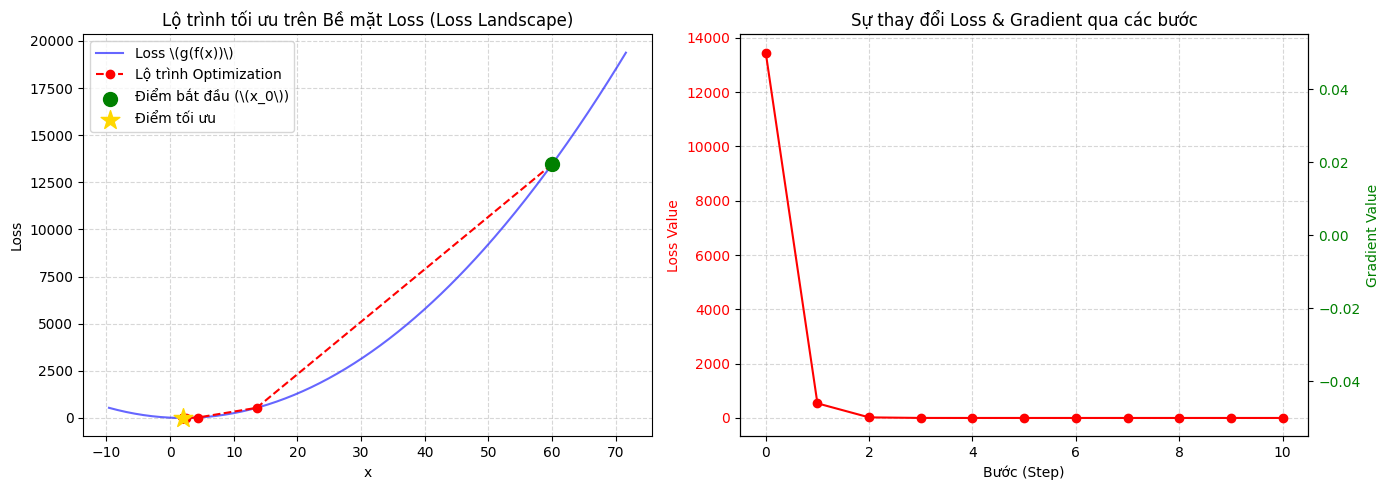

In [ ]:
# f(x) = 2x - 1     => df/dx = 2
# g(f) = (f - 3)^2  => dg/df = 2(f - 3)

x_start = 60.0
lr = 0.1

optimizer = CompositeOptimizer(
    f=lambda x: 2*x - 1,
    g=lambda f: (f - 3)**2,
    df_dx=lambda x: 2,
    dg_df=lambda f: 2*(f - 3),
    lr=lr
 )

# 1. Chạy tối ưu hóa
best_x, final_loss = optimizer.optimize(x_init=60.0, num_steps=10)

# 2. Hiển thị đồ thị trực quan hóa
optimizer.plot_optimization()